# Assignment 4: Implementation of ConvNets
## Name : Vikram krishnareddy
## student Id : 3220965

##  Downloading Images for Our Dataset

*  Before we can train a Convolutional Neural Network, we first need a dataset of images.  
For this assignment, the goal is binary image classification,that is  the model will learn to distinguish between two categories.

* I chose Cats and Dogs as my two classes because they are common objects and there are many images available online.

* Instead of manually collecting images, I use the bing-image-downloader library to automatically download images from Bing search.

* Since Bing sometimes limits the number of images returned for a single query, I use multiple related search queries to collect enough images. This helps ensure that I have at least 200 images per class, which is helpful for training a deep learning model.

* All images are downloaded locally in the Colab runtime so that the notebook can run completely without mounting Google Drive, which follows the assignment instructions.

#  Installing Libraries and Downloading Images

In [1]:
# Install the Bing image downloader library
!pip -q install bing-image-downloader

In [2]:
# Importing  the tools we need

import os
from bing_image_downloader import downloader

# Createing the  Folder

In [3]:
# Createing  a folder where all downloaded images will be stored.
# This folder will be inside the Colab runtime.

RAW_DIR = "/content/images_raw"

os.makedirs(RAW_DIR, exist_ok=True)

print("Images will be saved in:", RAW_DIR)

Images will be saved in: /content/images_raw


# Download Cat Images

In [4]:
# Now i am  downloading the  images of cats.
# I use two search queries to get more variety of images.

downloader.download("cute cats",limit=100,output_dir=RAW_DIR,adult_filter_off=True,force_replace=False)

downloader.download( "domestic cat close up",limit=100,output_dir=RAW_DIR,adult_filter_off=True,force_replace=False)

[%] Downloading Images to /content/images_raw/cute cats


[!!]Indexing page: 1

[%] Indexed 47 Images on Page 1.


[%] Downloading Image #1 from https://wallpapercave.com/wp/wp4346589.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://i.pinimg.com/736x/83/41/fd/8341fdbe6266e4a289f328b33115d358.jpg
[%] File Downloaded !

[%] Downloading Image #3 from https://i.pinimg.com/originals/b6/a6/d5/b6a6d50de7eb36065b98ebd254d46cd5.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://i.pinimg.com/originals/60/c3/9e/60c39e8dd446877c80527a540f143abf.jpg
[%] File Downloaded !

[%] Downloading Image #5 from https://wallup.net/wp-content/uploads/2019/09/620674-cats-fluffy-jump-animals-kitten-baby.jpg
[%] File Downloaded !

[%] Downloading Image #6 from https://static.vecteezy.com/system/resources/previews/027/955/785/large_2x/cute-little-kitten-cats-that-playing-together-at-playground-with-happiness-funny-moment-of-pet-fluffy-cat-with-generative-ai-free-photo.jpeg
[!] Issue g

# Download Dog Images

## Saving Images Locally

The images were downloaded using the Bing Image Downloader and saved locally in the Colab runtime.

Saving the images locally allows the notebook to run completely without mounting Google Drive, which was one of the assignment requirements.

After downloading, the images were organized into folders and later split into train, validation, and test datasets so they could be used with the Keras image generators.

In [5]:
# here  i am  downloading  images of dogs.
# Again i am  useing  two queries to get a larger dataset.

downloader.download("cute dogs",limit=100,output_dir=RAW_DIR,adult_filter_off=True,force_replace=False)

downloader.download("domestic dog close up",limit=100,output_dir=RAW_DIR,adult_filter_off=True,force_replace=False)

[%] Downloading Images to /content/images_raw/cute dogs


[!!]Indexing page: 1

[%] Indexed 47 Images on Page 1.


[%] Downloading Image #1 from https://fursnpaws.b-cdn.net/wp-content/uploads/2024/06/Two-fluffy-white-dogs.jpg
[%] File Downloaded !

[%] Downloading Image #2 from https://i.pinimg.com/736x/c4/a4/e3/c4a4e3d169ffabc5935a7e4f78e35637.jpg
[%] File Downloaded !

[%] Downloading Image #3 from https://media1.popsugar-assets.com/files/thumbor/-ABBtPX_haakjIbtoalsxKDIqs0/fit-in/1024x1024/filters:format_auto-!!-:strip_icc-!!-/2014/01/06/072/n/1922243/599fb6c890aeaf03_coversnow/i/Photos-Cute-Dogs-Wearing-Puffy-Coats.jpg
[%] File Downloaded !

[%] Downloading Image #4 from https://images.pexels.com/photos/5832817/pexels-photo-5832817.jpeg?cs=srgb&amp;dl=pexels-skyler-ewing-266953-5832817.jpg&amp;fm=jpg
[%] File Downloaded !

[%] Downloading Image #5 from https://i.pinimg.com/736x/62/a9/28/62a928d1f7eda1aa40217f54b6ab2b7f.jpg
[%] File Downloaded !

[%] Downloading Image #6 from https:

# Checking  if Images Downloaded or Not

In [10]:
# Finally, i am  checking  how many images were downloaded
# in each folder to make sure the dataset was created correctly.

import glob

def count_images(folder):
    extensions = (".jpg", ".jpeg", ".png", ".webp")
    files = [f for f in glob.glob(folder + "/*") if f.lower().endswith(extensions)]
    return len(files)

base = RAW_DIR
folders = ["cute cats","domestic cat close up","cute dogs","domestic dog close up"]

for folder in folders:
    path = os.path.join(base, folder)
    print(folder, ":", count_images(path), "images ")

cute cats : 100 images 
domestic cat close up : 100 images 
cute dogs : 100 images 
domestic dog close up : 100 images 


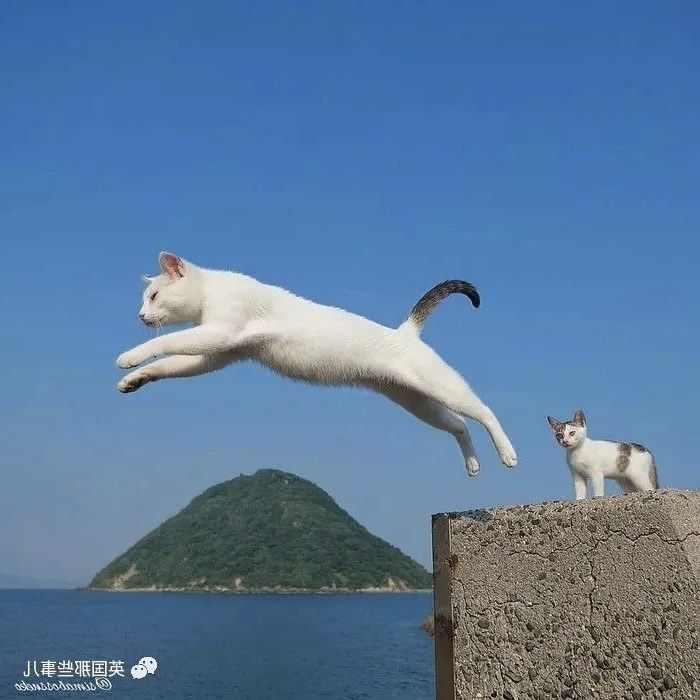

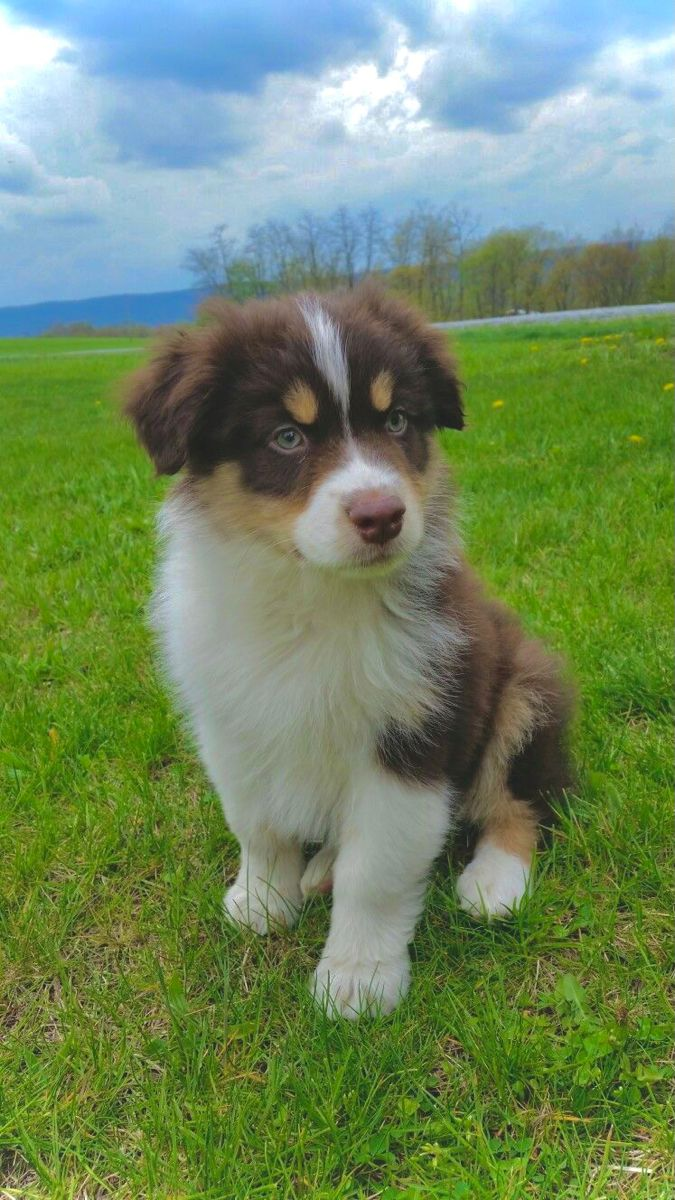

In [12]:
# here i am checking it the images are downloded correctly or not
from IPython.display import Image, display
import glob
import os

# Selecting  one image from each folder
cat_example = glob.glob(os.path.join(RAW_DIR, "cute cats", "*"))[0]
dog_example = glob.glob(os.path.join(RAW_DIR, "cute dogs", "*"))[0]

display(Image(filename=cat_example))


display(Image(filename=dog_example))

# Converting  an Image to a NumPy Array

## Converting an Image to a NumPy Array

* In this step, I loaded one sample image from the dataset and converted it into a NumPy array.
This helps understand how images are represented in deep learning. Instead of treating an image
as a picture, the model sees it as a matrix of numbers where each pixel has RGB values.

* For an RGB image, the NumPy array has the shape: height × width × 3.
This step helps verify that the images can be correctly loaded and processed before training the ConvNet model.

Example image path: /content/images_raw/cute cats/Image_92.jpg
Image shape: (700, 700, 3)


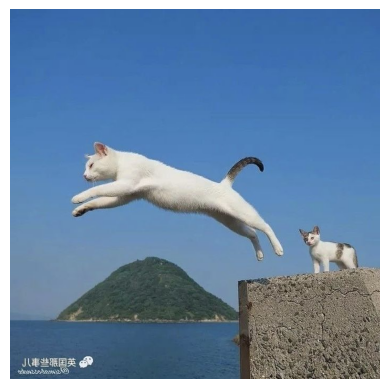

In [15]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

# Select one example image from the cats folder
example_image_path = glob.glob(os.path.join(RAW_DIR, "cute cats", "*"))[0]

print("Example image path:", example_image_path)

# Open the image
img = Image.open(example_image_path)

# Convert image to RGB format
img = img.convert("RGB")

# Convert image to NumPy array
img_array = np.array(img)

# Print shape of the image
print("Image shape:", img_array.shape)

# Display the image
plt.imshow(img_array)
plt.axis("off")
plt.show()

* In this step, I converted an image into a NumPy array using `np.array()`.
This shows that an image is not just a picture but actually a grid of numbers representing pixel values.
These numerical values are what the neural network uses as input during training.

# Combining  Images into Two Class Folders



* The images were downloaded using multiple search queries, so they were stored in separate folders.

* To prepare the dataset for training the ConvNet, I combined all cat images into one folder and all dog images into another folder.

* While doing this, I noticed that some images had the same filename (for example: Image_1.jpg).
If copied directly, these files could overwrite each other and reduce the total number of images.

* To avoid this issue, I renamed the files with unique names while copying them into the new class folders.
This ensures that no images are lost during the merge process.

In [17]:
## to do this step i used all the code from Ai but i made sure that i understood the code it generated

import os
import shutil
import glob

dataset_dir = "/content/dataset_all"
cats_dir = os.path.join(dataset_dir, "cats")
dogs_dir = os.path.join(dataset_dir, "dogs")

# Clear existing folders to avoid mixing old + new
if os.path.exists(cats_dir):
    shutil.rmtree(cats_dir)
if os.path.exists(dogs_dir):
    shutil.rmtree(dogs_dir)

os.makedirs(cats_dir, exist_ok=True)
os.makedirs(dogs_dir, exist_ok=True)

cat_folders = ["cute cats", "domestic cat close up"]
dog_folders = ["cute dogs", "domestic dog close up"]

VALID_EXTS = (".jpg", ".jpeg", ".png", ".webp")

def copy_with_unique_names(src_folder, dst_folder, prefix, start_count=0):
    count = start_count
    for fp in glob.glob(os.path.join(src_folder, "*")):
        if not fp.lower().endswith(VALID_EXTS):
            continue
        new_name = f"{prefix}_{count}" + os.path.splitext(fp)[1].lower()
        shutil.copy(fp, os.path.join(dst_folder, new_name))
        count += 1
    return count

# Copy cats
cat_count = 0
for folder in cat_folders:
    src = os.path.join(RAW_DIR, folder)
    cat_count = copy_with_unique_names(src, cats_dir, "cat", cat_count)

# Copy dogs
dog_count = 0
for folder in dog_folders:
    src = os.path.join(RAW_DIR, folder)
    dog_count = copy_with_unique_names(src, dogs_dir, "dog", dog_count)

print("Cats images:", len(os.listdir(cats_dir)))
print("Dogs images:", len(os.listdir(dogs_dir)))

Cats images: 200
Dogs images: 200


  # Create Train / Validation / Test Split



* Now that all cat images are in one folder and all dog images are in one folder, the next step is to split the dataset.

• Training set (70%)- used to train the model  
•Validation set (15%) - used to monitor the model during training  
• Test set (15%) – used to evaluate the final model on unseen images



In [19]:
import os
import glob
import random
import shutil

# I set a random seed so the split stays the same every time the notebook runs
random.seed(42)

# These are the folders that contain all cat and dog images
cats_source = "/content/dataset_all/cats"
dogs_source = "/content/dataset_all/dogs"

# This will be the new folder where the split dataset will be stored
dataset_split = "/content/dataset_split"

train_dir = os.path.join(dataset_split, "train")
val_dir = os.path.join(dataset_split, "val")
test_dir = os.path.join(dataset_split, "test")

# Create the folder structure needed for training
for base in [train_dir, val_dir, test_dir]:
    os.makedirs(os.path.join(base, "cats"), exist_ok=True)
    os.makedirs(os.path.join(base, "dogs"), exist_ok=True)

# I will split the data roughly as 70% train, 15% validation, and 15% test
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15

def split_images(class_name, source_folder):

    # Get all images from the source folder
    images = glob.glob(source_folder + "/*")

    # Shuffle the images so the split is random
    random.shuffle(images)

    total = len(images)

    train_count = int(total * TRAIN_RATIO)
    val_count = int(total * VAL_RATIO)

    train_images = images[:train_count]
    val_images = images[train_count:train_count + val_count]
    test_images = images[train_count + val_count:]

    # Copy images into the train folder
    for img in train_images:
        shutil.copy(img, os.path.join(train_dir, class_name))

    # Copy images into the validation folder
    for img in val_images:
        shutil.copy(img, os.path.join(val_dir, class_name))

    # Copy images into the test folder
    for img in test_images:
        shutil.copy(img, os.path.join(test_dir, class_name))

    return len(train_images), len(val_images), len(test_images)


cats_split = split_images("cats", cats_source)
dogs_split = split_images("dogs", dogs_source)


print("Cats (train, val, test):", cats_split)
print("Dogs (train, val, test):", dogs_split)

Cats (train, val, test): (140, 30, 30)
Dogs (train, val, test): (140, 30, 30)


# Load the Data Using Image Generators



* Now that the dataset is organized into train, validation, and test folders, the next step is to load these images so they can be used to train the ConvNet model.

* Instead of loading all images at once, I use Keras **ImageDataGenerator**, which reads the images in small batches during training. This is more efficient and avoids memory issues.

* While loading the images, I also rescale the pixel values from 0–255 to 0–1. This normalization helps the neural network train more effectively.

* The generator also automatically assigns labels based on the folder names (cats and dogs), which makes it easy for the model to learn the difference between the two classes.

In [20]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

# These are the folders we created in the previous step
train_path = "/content/dataset_split/train"
val_path   = "/content/dataset_split/val"
test_path  = "/content/dataset_split/test"

# We choose a fixed image size so every image becomes the same shape for the ConvNet
IMG_SIZE = (180, 180)
BATCH_SIZE = 32

# Rescale = convert pixel values from 0-255 to 0-1 (this helps training)
train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

# Training generator (shuffling ON because we want random batches while training)
train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

# Validation generator (shuffling OFF is fine; we just evaluate during training)
val_gen = val_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

# Test generator (shuffling OFF so evaluation is stable and labels align)
test_gen = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

print("\nClass label mapping (important):", train_gen.class_indices)

Found 278 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Found 60 images belonging to 2 classes.

Class label mapping (important): {'cats': 0, 'dogs': 1}


The output shows that the images were successfully loaded using the image generators.

• The training dataset contains **278 images** belonging to **2 classes** (cats and dogs).  
• The validation dataset contains **60 images** belonging to **2 classes**.  
• The test dataset contains **60 images** belonging to **2 classes**.

The class label mapping also shows how the generator assigns labels:
- cats = 0
- dogs = 1

This means the model will learn to classify images as either cat (0) or dog (1).

#  Building the ConvNet Model

## now that the dataset is prepared and loaded using image generators, the next step is to build a convolutional neural network model to classify the images.



* Now I will build a simple Convolutional Neural Network (ConvNet) to classify the images as cats or dogs.

* ConvNets are designed for image data. They work by detecting patterns such as edges, shapes, and textures in images.

* The model will use several **convolution layers** to extract features from the images and **pooling layers** to reduce the image size and keep the most important information.

* At the end, the model will use a **dense layer with a sigmoid activation function** to predict whether the image is a cat or a dog.

In [21]:
from tensorflow.keras import layers
from tensorflow.keras import models

# Build a simple ConvNet model
model = models.Sequential()

# First convolution layer
model.add(layers.Conv2D(32, (3,3), activation="relu", input_shape=(180,180,3)))
model.add(layers.MaxPooling2D((2,2)))

# Second convolution layer
model.add(layers.Conv2D(64, (3,3), activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# Third convolution layer
model.add(layers.Conv2D(128, (3,3), activation="relu"))
model.add(layers.MaxPooling2D((2,2)))

# Flatten layer converts feature maps into a vector
model.add(layers.Flatten())

# Dense layer for learning patterns
model.add(layers.Dense(128, activation="relu"))

# Output layer for binary classification (cat vs dog)
model.add(layers.Dense(1, activation="sigmoid"))

# Compile the model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Show model structure
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,105 (25.36 MB)

 Trainable params: 6,647,105 (25.36 MB)

 Non-trainable params: 0 (0.00 B)



The model summary shows that the ConvNet was created successfully.

It contains:
- **3 convolution layers** to learn image features like edges, shapes, and textures
- **3 max pooling layers** to reduce the image size and keep important information
- **1 flatten layer** to convert the feature maps into a single long vector
- **1 dense hidden layer** to learn patterns from those features
- **1 output layer** to predict whether the image is a cat or a dog

The total number of trainable parameters is **6,647,105**, which means the model has many values that will be updated during training.

This step is important because it defines the architecture of the ConvNet before fitting it on the training data.

# Training the ConvNet Model

* In this step, I train the ConvNet using the training images.
* The model will learn patterns from the cat and dog images and try to improve its predictions over multiple rounds, called epochs.

* I will also use the validation data during training so I can compare how well the model is learning on unseen images after each epoch.

* This helps check whether the model is improving properly or starting to overfit.

In [22]:
# Train the ConvNet model

history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 46s 5s/step - accuracy: 0.5119 - loss: 1.1466 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5443 - loss: 0.6921 - val_accuracy: 0.5000 - val_loss: 0.7052
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5387 - loss: 0.6974 - val_accuracy: 0.5000 - val_loss: 0.6887
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 3s/step - accuracy: 0.6662 - loss: 0.6606 - val_accuracy: 0.5000 - val_loss: 0.7358
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6453 - loss: 0.6284 - val_accuracy: 0.5500 - val_loss: 0.6975
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.7456 - loss: 0.5543 - val_accuracy: 0.5000 - val_loss: 0.7608
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - accuracy: 0.8383 - loss: 0.4198 - val_accuracy: 0.5000 - val_loss: 0.8058
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.7570 - loss: 0.4466 - val_accuracy: 0.5667 - val_loss: 0.8561
Epoch 9/

## What happened during training

* The model was trained for 10 epochs using the training dataset, and validation performance was checked after each epoch.

* From the results, the **training accuracy kept improving** and reached around **91.6%** by the final epoch.  
This means the model was learning patterns from the training images.

* However, the **validation accuracy stayed much lower**, around **50% to 56.7%**, and the validation loss increased over time.  

* This suggests that the model is likely **overfitting**, which means it is learning the training images well but is not generalizing well to new images.

* i think this is becasue the dataset is small or when the model is too complex for the amount of data available.

# Evaluating the ConvNet Model


* After training the model, the next step is to evaluate how well it performs on the test dataset.

* The test set contains images the model has not seen before.  
* This gives a better idea of how well the model can classify new cat and dog images.

* Here I will use the test generator to calculate the final test loss and test accuracy.

In [23]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_gen)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.6403 - loss: 0.9840
Test Loss: 1.1188100576400757
Test Accuracy: 0.6166666746139526


##  the test results

* After training, I evaluated the model on the test dataset, which contains images the model had not seen before.

* The model got a **test accuracy of 61.67%**, which means it correctly classified about 62 out of every 100 test images.

* The **test loss was 1.1188**, which shows that the model still made some incorrect predictions with high confidence.

* Compared to the training accuracy, the test accuracy is much lower. This again suggests that the model is **overfitting**.  
* so the model learned the training images well, but it did not generalize as well to new unseen images.


# Plot Training vs Validation Performance

* Here I plot the **training accuracy and validation accuracy** to see how the model improved while learning.

* I also plot the **training loss and validation loss** to understand how the prediction error changed during training.

* These plots help identify issues such as overfitting or underfitting.

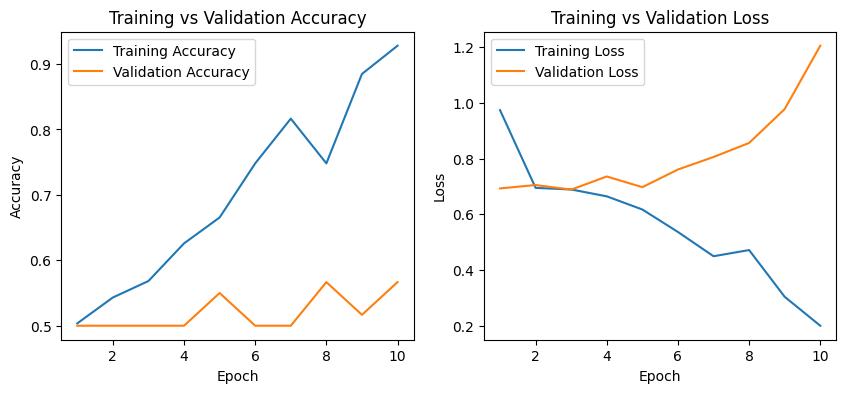

In [24]:
import matplotlib.pyplot as plt

# Extract values from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot accuracy
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot loss
plt.subplot(1,2,2)
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()



* From the loss graph, the **training loss kept decreasing**, which means the model was fitting the training data better over time.  
* At the same time, the **validation loss started increasing**, which indicates that the model was not performing well on unseen validation images.

* This pattern suggests that the model is **overfitting**. The model is learning the training images very well but is not generalizing well to new images.

# What I learned from this assignment



• In this assignment, I learned how to automatically collect image datasets using the Bing Image Downloader library instead of manually gathering images.

• I also learned how to save the downloaded images locally in the Colab runtime and organize them into proper folders for machine learning.

• I understood how images are represented as numerical data. By converting an image into a NumPy array using `np.array()`, the image becomes a matrix of pixel values where each pixel contains RGB numbers.

• I learned how to split the dataset into training, validation, and test sets so the model can be trained and evaluated properly.

• I also learned how convolutional neural networks extract features from images and how to monitor model performance using accuracy and loss graphs.